# Model Graphs

Four illustrative figures for the theoretical framework (supply-shock model).

- **Fig 1** `fig_preai.png` — pre-AI wage schedule
- **Fig 2** `fig_postai.png` — post-AI shock: supply dilution vs output expansion
- **Fig 3** `fig_capability.png` — increasing AI capability: expanding the frontier
- **Fig 4** `fig_multiple.png` — non-monotone AI supply: scattered wage compression

Output to `../output/model/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import os

os.makedirs('../output/model', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
sigma  = 2.0
I_star = 0.4

i_fine = np.linspace(0, 1, 2000)   # dense grid for integration

# ── Primitives (directly defined) ─────────────────────────────────────────────
def f_human(i):
    """Human task supply: downward-sloping (routine tasks more abundant)."""
    return 2.0 - 1.2 * np.asarray(i, dtype=float)

def s_ai(i, I_s=None, s_b=3.0):
    """AI task supply: linearly decreasing to 0 at I*."""
    i = np.asarray(i, dtype=float)
    if I_s is None: I_s = I_star
    return s_b * np.maximum(0.0, 1.0 - i / I_s)

# ── CES equilibrium (P_Y = 1 normalisation) ──────────────────────────────────
def compute_eq(supply_vals):
    """CES output from supply values on i_fine grid."""
    int_Y = np.trapezoid(supply_vals**((sigma - 1) / sigma), i_fine)
    return int_Y**(sigma / (sigma - 1))

def wage_from_supply(Y, supply):
    """w(i) = (Y / y(i))^{1/sigma}."""
    return (Y / supply)**(1 / sigma)

# Pre-AI equilibrium
f_vals  = f_human(i_fine)
Y0      = compute_eq(f_vals)
w0_vals = wage_from_supply(Y0, f_vals)

print(f'sigma = {sigma},  I* = {I_star}')
print(f'Y0 = {Y0:.4f}')
print(f'w0 range: [{w0_vals.min():.3f}, {w0_vals.max():.3f}]')

sigma = 2.0,  I* = 0.4
Y0 = 1.3779
w0 range: [0.830, 1.312]


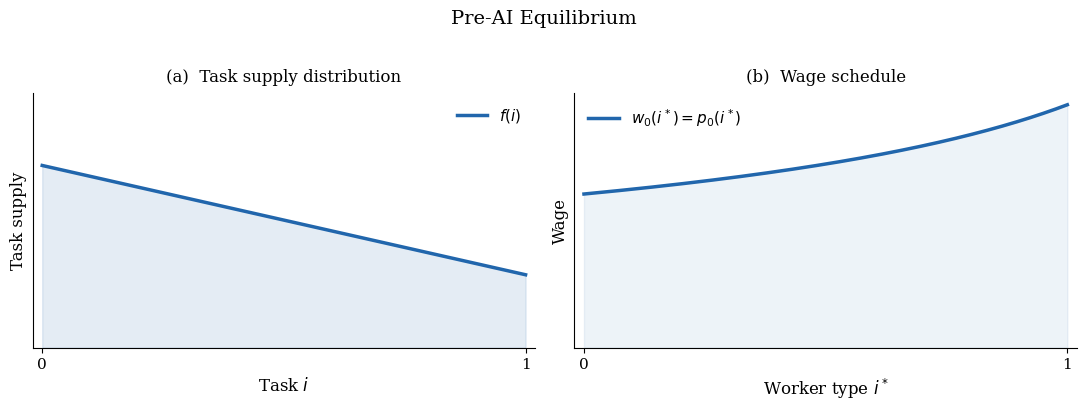

Saved fig_preai.png


In [3]:
# ── Figure 1: Pre-AI Equilibrium (supply | wage) ─────────────────────────────
fig, (ax_s, ax_w) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Task supply
ax_s.fill_between(i_fine, 0, f_vals, alpha=0.12, color='#2166ac')
ax_s.plot(i_fine, f_vals, color='#2166ac', lw=2.5, label=r'$f(i)$')
ax_s.set_xlabel(r'Task $i$', fontsize=12)
ax_s.set_ylabel('Task supply', fontsize=12)
ax_s.set_title('(a)  Task supply distribution', fontsize=12, pad=8)
ax_s.set_xlim(-0.02, 1.02)
ax_s.set_ylim(0, 2.8)
ax_s.set_xticks([0, 1])
ax_s.set_yticks([])
ax_s.legend(fontsize=11, framealpha=0, loc='upper right')

# (b) Wage schedule
ax_w.plot(i_fine, w0_vals, color='#2166ac', lw=2.5,
          label=r'$w_0(i^*) = p_0(i^*)$')
ax_w.fill_between(i_fine, 0, w0_vals, alpha=0.08, color='#2166ac')
ax_w.set_xlabel(r'Worker type $i^*$', fontsize=12)
ax_w.set_ylabel('Wage', fontsize=12)
ax_w.set_title('(b)  Wage schedule', fontsize=12, pad=8)
ax_w.set_xlim(-0.02, 1.02)
ax_w.set_ylim(0)
ax_w.set_xticks([0, 1])
ax_w.set_yticks([])
ax_w.legend(fontsize=11, framealpha=0, loc='upper left')

fig.suptitle('Pre-AI Equilibrium', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_preai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_preai.png')

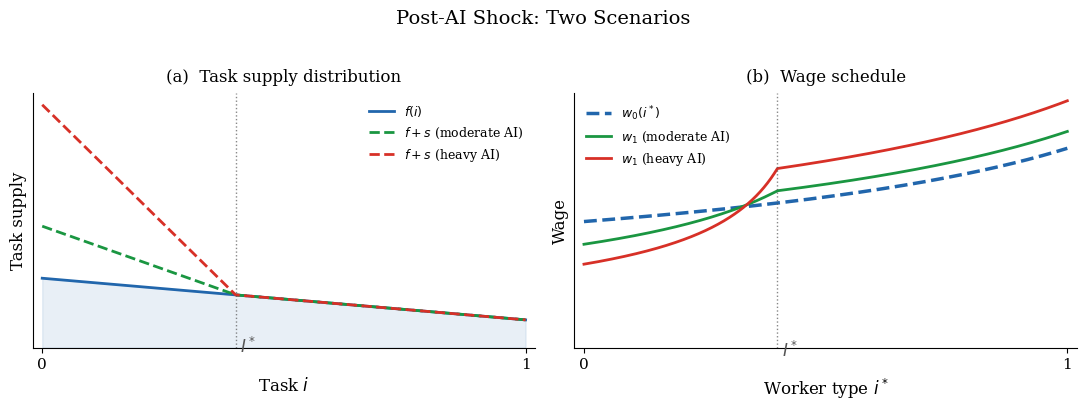

Saved fig_postai.png


In [4]:
# ── Figure 2: Post-AI Supply Shock (two scenarios) ────────────────────────────
s_bars   = [1.5, 5.0]
s_colors = ['#1a9641', '#d73027']
s_labels = ['moderate AI', 'heavy AI']

fig, (ax_s, ax_w) = plt.subplots(1, 2, figsize=(11, 4))

# ── (a) Task supply ──────────────────────────────────────────────────────────
# Human baseline
ax_s.fill_between(i_fine, 0, f_vals, alpha=0.10, color='#2166ac')
ax_s.plot(i_fine, f_vals, color='#2166ac', lw=2, label=r'$f(i)$')

for sb, col, lbl in zip(s_bars, s_colors, s_labels):
    ybar = f_vals + s_ai(i_fine, s_b=sb)
    ax_s.plot(i_fine, ybar, color=col, lw=2, ls='--',
              label=rf'$f + s$ ({lbl})')

ax_s.axvline(I_star, color='#555555', lw=1, ls=':', alpha=0.7)
ax_s.annotate(r'$I^*$', xy=(I_star, 0), xytext=(I_star + 0.01, -0.15),
              ha='left', fontsize=12, color='#555555',
              annotation_clip=False)
ax_s.set_xlabel(r'Task $i$', fontsize=12)
ax_s.set_ylabel('Task supply', fontsize=12)
ax_s.set_title('(a)  Task supply distribution', fontsize=12, pad=8)
ax_s.set_xlim(-0.02, 1.02)
ax_s.set_ylim(0)
ax_s.set_xticks([0, 1])
ax_s.set_yticks([])
ax_s.legend(fontsize=9, framealpha=0, loc='upper right')

# ── (b) Wage schedule ────────────────────────────────────────────────────────
ax_w.plot(i_fine, w0_vals, color='#2166ac', lw=2.5, ls='--',
          label=r'$w_0(i^*)$')

for sb, col, lbl in zip(s_bars, s_colors, s_labels):
    ybar_vals = f_vals + s_ai(i_fine, s_b=sb)
    Ybar      = compute_eq(ybar_vals)
    w1_vals   = wage_from_supply(Ybar, ybar_vals)
    ax_w.plot(i_fine, w1_vals, color=col, lw=2,
              label=rf'$w_1$ ({lbl})')

ax_w.axvline(I_star, color='#555555', lw=1, ls=':', alpha=0.7)
ax_w.annotate(r'$I^*$', xy=(I_star, 0), xytext=(I_star + 0.01, -0.06),
              ha='left', fontsize=12, color='#555555',
              annotation_clip=False)
ax_w.set_xlabel(r'Worker type $i^*$', fontsize=12)
ax_w.set_ylabel('Wage', fontsize=12)
ax_w.set_title('(b)  Wage schedule', fontsize=12, pad=8)
ax_w.set_xlim(-0.02, 1.02)
ax_w.set_ylim(0)
ax_w.set_xticks([0, 1])
ax_w.set_yticks([])
ax_w.legend(fontsize=9, framealpha=0, loc='upper left')

fig.suptitle('Post-AI Shock: Two Scenarios', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_postai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_postai.png')

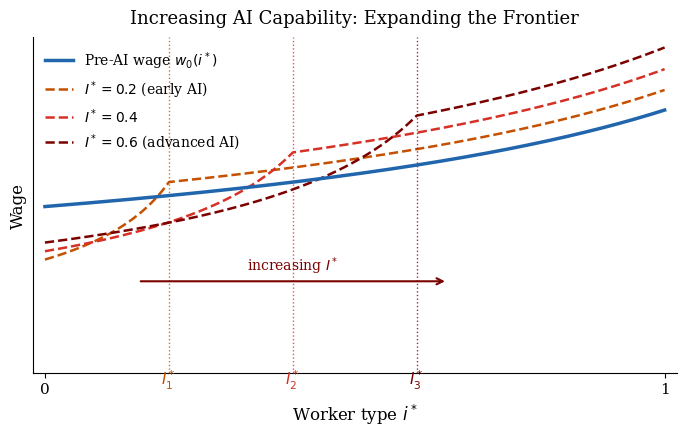

Saved fig_capability.png


In [5]:
# ── Figure 3: Increasing AI Capability ────────────────────────────────────────
I_stars     = [0.2, 0.4, 0.6]
cap_colors  = ['#c45000', '#d73027', '#7b0000']
cap_labels  = [
    r'$I^*=0.2$ (early AI)',
    r'$I^*=0.4$',
    r'$I^*=0.6$ (advanced AI)',
]
I_labels = [r'$I^*_1$', r'$I^*_2$', r'$I^*_3$']

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(i_fine, w0_vals, color='#2166ac', lw=2.5,
        label=r'Pre-AI wage $w_0(i^*)$', zorder=5)

for I_s, color, lbl in zip(I_stars, cap_colors, cap_labels):
    ybar_vals = f_vals + s_ai(i_fine, I_s=I_s)
    Ybar      = compute_eq(ybar_vals)
    w1_vals   = wage_from_supply(Ybar, ybar_vals)
    ax.plot(i_fine, w1_vals, color=color, lw=1.8, ls='--', label=lbl)
    ax.axvline(I_s, color=color, lw=1.0, ls=':', alpha=0.8)

for k, I_s in enumerate(I_stars):
    ax.annotate(I_labels[k], xy=(I_s, 0), xytext=(I_s, -0.06),
                ha='center', fontsize=11, color=cap_colors[k],
                annotation_clip=False)

ax.annotate('', xy=(0.65, w0_vals.min() * 0.55),
            xytext=(0.15, w0_vals.min() * 0.55),
            arrowprops=dict(arrowstyle='->', color='#7b0000', lw=1.5))
ax.text(0.40, w0_vals.min() * 0.62, r'increasing $I^*$',
        fontsize=10, color='#7b0000', ha='center')

ax.set_xlabel(r'Worker type $i^*$', fontsize=12)
ax.set_ylabel('Wage', fontsize=12)
ax.set_title('Increasing AI Capability: Expanding the Frontier',
             fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.legend(fontsize=10, framealpha=0, loc='upper left')

plt.tight_layout()
plt.savefig('../output/model/fig_capability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_capability.png')

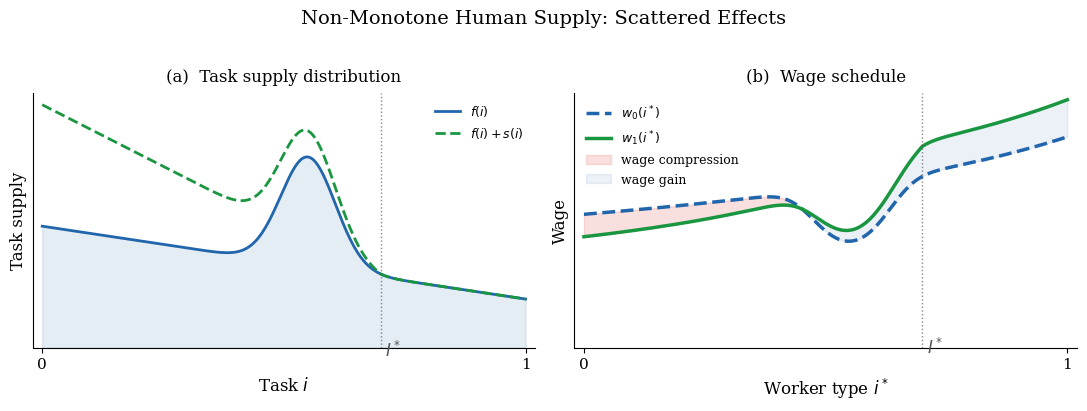

Saved fig_multiple.png


In [6]:
# ── Figure 4: Non-Monotone Human Supply ───────────────────────────────────────
# When f(i) has a bump (e.g. many workers clustered in a mid-complexity task),
# the pre-AI wage dips there; AI supply can then dominate in scattered regions.

def f_nonmono(i):
    """Non-monotone human supply: base decline + bump near i~0.55."""
    i = np.asarray(i, dtype=float)
    base = 2.0 - 1.2 * i
    bump = 1.8 * np.exp(-((i - 0.55) / 0.08)**2)
    return base + bump

# Use a wider AI frontier so the bump at i~0.55 falls inside the AI range
I_star_nm = 0.7
s_b_nm    = 2.0

f_nm_vals   = f_nonmono(i_fine)
Y0_nm       = compute_eq(f_nm_vals)
w0_nm_vals  = wage_from_supply(Y0_nm, f_nm_vals)

ybar_nm     = f_nm_vals + s_ai(i_fine, I_s=I_star_nm, s_b=s_b_nm)
Ybar_nm     = compute_eq(ybar_nm)
w1_nm_vals  = wage_from_supply(Ybar_nm, ybar_nm)

fig, (ax_s, ax_w) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Supply
ax_s.fill_between(i_fine, 0, f_nm_vals, alpha=0.12, color='#2166ac')
ax_s.plot(i_fine, f_nm_vals, color='#2166ac', lw=2, label=r'$f(i)$')
ax_s.plot(i_fine, ybar_nm, color='#1a9641', lw=2, ls='--',
          label=r'$f(i) + s(i)$')
ax_s.axvline(I_star_nm, color='#555555', lw=1, ls=':', alpha=0.7)
ax_s.annotate(r'$I^*$', xy=(I_star_nm, 0), xytext=(I_star_nm + 0.01, -0.15),
              ha='left', fontsize=12, color='#555555',
              annotation_clip=False)
ax_s.set_xlabel(r'Task $i$', fontsize=12)
ax_s.set_ylabel('Task supply', fontsize=12)
ax_s.set_title('(a)  Task supply distribution', fontsize=12, pad=8)
ax_s.set_xlim(-0.02, 1.02)
ax_s.set_ylim(0)
ax_s.set_xticks([0, 1])
ax_s.set_yticks([])
ax_s.legend(fontsize=9, framealpha=0, loc='upper right')

# (b) Wage
ax_w.plot(i_fine, w0_nm_vals, color='#2166ac', lw=2.5, ls='--',
          label=r'$w_0(i^*)$')
ax_w.plot(i_fine, w1_nm_vals, color='#1a9641', lw=2.5,
          label=r'$w_1(i^*)$')

ax_w.fill_between(i_fine, w1_nm_vals, w0_nm_vals,
                  where=(w1_nm_vals < w0_nm_vals),
                  alpha=0.15, color='#d73027', label='wage compression')
ax_w.fill_between(i_fine, w0_nm_vals, w1_nm_vals,
                  where=(w1_nm_vals > w0_nm_vals),
                  alpha=0.10, color='#4575b4', label='wage gain')

ax_w.axvline(I_star_nm, color='#555555', lw=1, ls=':', alpha=0.7)
ax_w.annotate(r'$I^*$', xy=(I_star_nm, 0), xytext=(I_star_nm + 0.01, -0.04),
              ha='left', fontsize=12, color='#555555',
              annotation_clip=False)
ax_w.set_xlabel(r'Worker type $i^*$', fontsize=12)
ax_w.set_ylabel('Wage', fontsize=12)
ax_w.set_title('(b)  Wage schedule', fontsize=12, pad=8)
ax_w.set_xlim(-0.02, 1.02)
ax_w.set_ylim(0)
ax_w.set_xticks([0, 1])
ax_w.set_yticks([])
ax_w.legend(fontsize=9, framealpha=0, loc='upper left')

fig.suptitle('Non-Monotone Human Supply: Scattered Effects',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_multiple.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_multiple.png')